# 05 — Model Evaluation
### Chicago Housing Market | Listing Risk Prediction

In notebook 04 we trained four models. Now we **evaluate their true performance** on the test set — data the models have never seen.

**What this notebook does:**
1. Load all trained models and the test data
2. Evaluate both regression models (R², RMSE, MAE, charts)
3. Evaluate both classification models (accuracy, F1, confusion matrix, ROC curve)
4. Rank feature importance
5. Produce a final comparison table

**Input:** Models from `models/` + `data/processed/chicago_housing_engineered.csv`

### Why Evaluate on a Separate Test Set?

**Overfitting** is when a model memorises the training data instead of learning general patterns. An overfit model performs great on training data but fails on new data — like a student who memorises answers instead of understanding the subject.

The test set is our reality check. It simulates how the model would perform on truly new, future data.

Key rule: **the test set is only touched once** — when reporting final results. Never use test set results to tune the model (that would be cheating).

### What are we doing in this cell?

We load the saved models, scaler, and feature column list from disk. Then we recreate the same train/test split from notebook 04 using the same 80% cutoff index.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import matplotlib.dates as mdates
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix, roc_curve, 
    roc_auc_score
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

# Load models and scaler
lr = joblib.load('../models/linear_regression.pkl')
rf_reg = joblib.load('../models/rf_regressor.pkl')
log_clf = joblib.load('../models/logistic_regression.pkl')
rf_clf  = joblib.load('../models/rf_classifier.pkl')
scaler  = joblib.load('../models/scaler.pkl')
FEATURE_COLS = joblib.load('../models/feature_cols.pkl')

# Load data and recreate split
df= pd.read_csv('../data/processed/chicago_housing_engineered.csv')
df['PERIOD_BEGIN']= pd.to_datetime(df['PERIOD_BEGIN'])
df= df.sort_values('PERIOD_BEGIN').reset_index(drop=True)

train_size = int(len(df) * 0.8) 
test_size = len(df) - train_size
X = df[FEATURE_COLS]
y_reg = df['RISK_SCORE']
y_clf = df['RISK_LABEL']

X_train = X.head(train_size)
X_test = X.tail(test_size)

X_train_sc = scaler.transform(X_train)
X_test_sc = scaler.transform(X_test)

y_reg_test = y_reg.tail(test_size)
y_clf_test = y_clf.tail(test_size)
dates_test = df['PERIOD_BEGIN'].tail(test_size)

print('Test rows:', len(y_reg_test))
print('Test period:', dates_test.min().date(), 'to', dates_test.max().date())




Test rows: 31
Test period: 2023-06-01 to 2025-12-01


---
## 1. Regression Evaluation

### What are we doing in this cell?

We evaluate both regression models on the **test set** and compare three metrics:

| Metric | Formula | Meaning |
|--------|---------|--------|
| **R²** | 1 − (SS_res / SS_tot) | % of variance explained. 1.0 = perfect |
| **RMSE** | √(mean of squared errors) | Average error in target units |
| **MAE** | mean(\|actual − predicted\|) | Average absolute error (less sensitive to big outliers than RMSE) |

In [33]:
def reg_metrics(model, X_sc, y_true, name):
    y_pred = model.predict(X_sc)
    r2 = r2_score(y_true,y_pred )
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae= mean_absolute_error(y_true, y_pred)

    print(f'___{name}______________')
    print(f' R2: {r2:.4f}')
    print(f'RMSE: {rmse: .4f}')
    print(f' MAE: {mae:.4f}')
    return y_pred, {'model': name,'R2': r2, 'RMSE':rmse, 'MAE': mae}

y_pred_lr, metrics_lr = reg_metrics(lr, X_test_sc, y_reg_test, 'Linear Regression(test)')
y_pred_rfr,  metrics_rfr  = reg_metrics(rf_reg, X_test_sc, y_reg_test, 'Random Forest Regressor (test)')


    

___Linear Regression(test)______________
 R2: 0.2362
RMSE:  0.2212
 MAE: 0.1826
___Random Forest Regressor (test)______________
 R2: -0.6444
RMSE:  0.3245
 MAE: 0.2550


### What are we doing in this cell?

We plot **actual vs predicted** values over time for both regression models. A good model's predicted line should closely follow the actual line.

We also plot a **residual plot** — residuals are the errors (actual − predicted). For a well-behaved model:
- Residuals should be randomly scattered around zero
- There should be no visible pattern (if there is a pattern, the model is missing something)

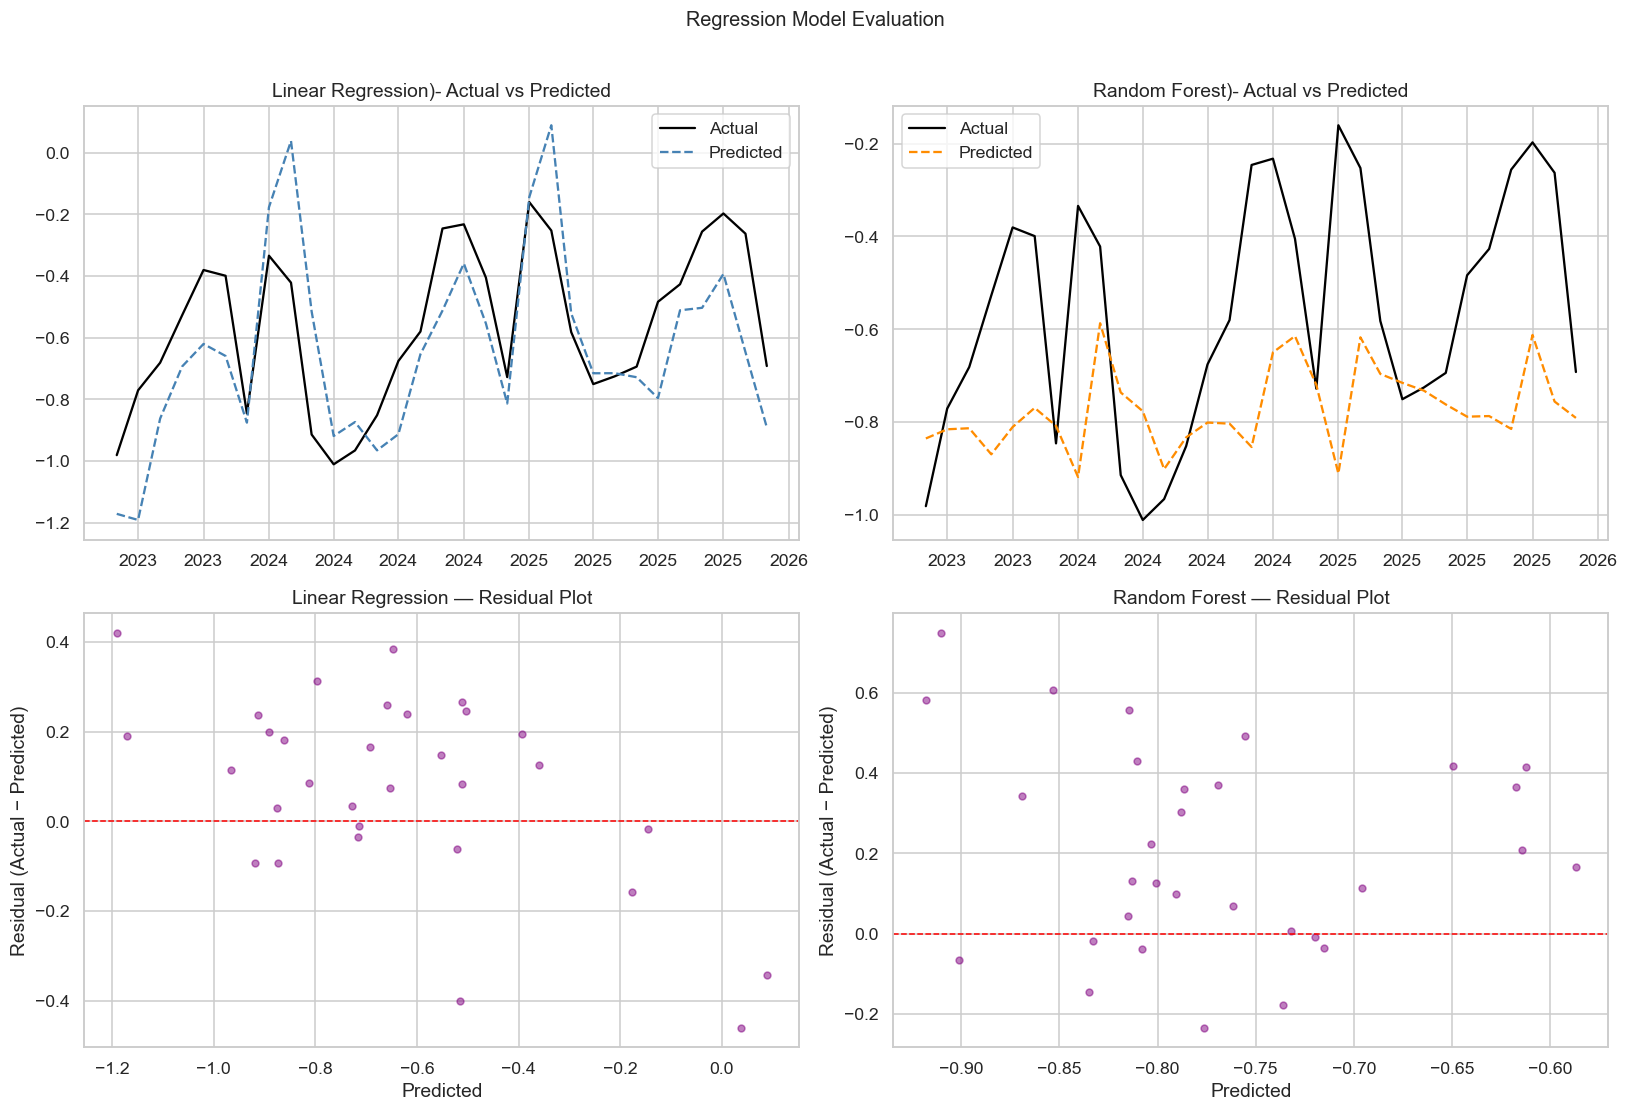

In [34]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

for ax,y_pred, name, color in [
    (axes[0,0], y_pred_lr, 'Linear Regression', 'steelblue'),
    (axes[0,1], y_pred_rfr, 'Random Forest', 'darkorange')
]:
    ax.plot(dates_test, y_reg_test.values, label='Actual', color='black', linewidth=1.5)
    ax.plot(dates_test, y_pred, label='Predicted', color=color, linewidth=1.5, linestyle='--')
    ax.set_title(f'{name})- Actual vs Predicted')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for ax, y_pred, name in [
    (axes[1,0], y_pred_lr, 'Linear Regression'),
    (axes[1,1], y_pred_rfr, 'Random Forest')
]:
    residuals= y_reg_test.values - y_pred
    ax.scatter(y_pred, residuals, alpha=0.5, s=20, color='purple')
    ax.axhline(0, color='red', linewidth=1, linestyle='--')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual (Actual − Predicted)')
    ax.set_title(f'{name} — Residual Plot')

plt.suptitle('Regression Model Evaluation', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
            

---
## 2. Classification Evaluation

### What are we doing in this cell?

For classification we use a **confusion matrix** — a 2×2 table showing how predictions compare to actual labels:

```
                  Predicted Low   Predicted High
Actual Low Risk  [ True Negative   False Positive ]
Actual High Risk [ False Negative  True Positive  ]
```

- **True Positive (TP)** — correctly predicted high risk ✅
- **True Negative (TN)** — correctly predicted low risk ✅
- **False Positive (FP)** — predicted high risk but was low risk ❌ (false alarm)
- **False Negative (FN)** — predicted low risk but was actually high risk ❌ (missed a risk period — the worse kind of error for our use case)

── Logistic Regression ──────────────────────
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00        31
   High Risk       0.00      0.00      0.00         0

   micro avg       1.00      1.00      1.00        31
   macro avg       0.50      0.50      0.50        31
weighted avg       1.00      1.00      1.00        31

── Random Forest Classifier ──────────────────────
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00        31
   High Risk       0.00      0.00      0.00         0

   micro avg       1.00      1.00      1.00        31
   macro avg       0.50      0.50      0.50        31
weighted avg       1.00      1.00      1.00        31



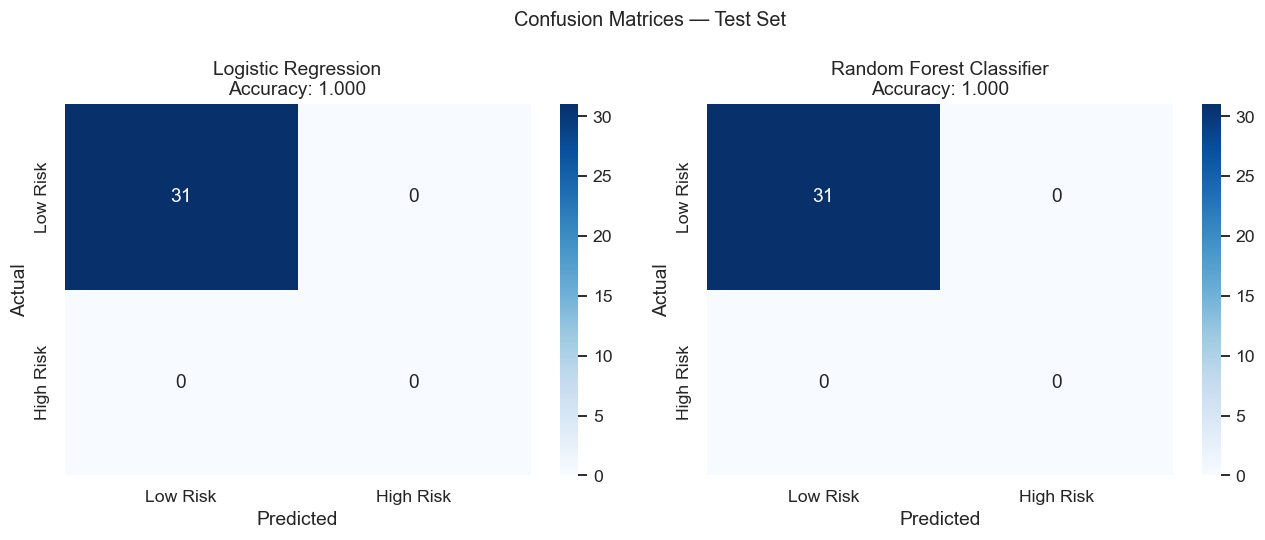

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, name in [
    (axes[0], log_clf, 'Logistic Regression'),
    (axes[1], rf_clf,  'Random Forest Classifier')
]:
    y_pred = model.predict(X_test_sc)
    acc = accuracy_score(y_clf_test, y_pred)
    cm = confusion_matrix(y_clf_test, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Low Risk', 'High Risk'],
                yticklabels=['Low Risk', 'High Risk'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{name}\nAccuracy: {acc:.3f}')
    print(f'── {name} ──────────────────────')
    print(classification_report(y_clf_test, y_pred, labels=[0, 1],
                                target_names=['Low Risk', 'High Risk'],
                                zero_division=0))

plt.suptitle('Confusion Matrices — Test Set', fontsize=13)
plt.tight_layout()
plt.show()

### What are we doing in this cell?

The **ROC curve** (Receiver Operating Characteristic) shows the trade-off between:
- **True Positive Rate (Recall)** — how many actual high-risk months we catch
- **False Positive Rate** — how many low-risk months we wrongly flag as high risk

A perfect model's curve goes to the top-left corner. A random model follows the diagonal.

**AUC (Area Under the Curve)** summarises the ROC curve in one number:
- `AUC = 1.0` → perfect model
- `AUC = 0.5` → no better than random guessing

In [36]:
if y_clf_test.nunique() < 2:
    print('ROC/AUC is unavailable: this test period contains only Low Risk months.')
else:
    fig, ax = plt.subplots(figsize=(7, 6))

    for model, name, color in [
        (log_clf, 'Logistic Regression', 'steelblue'),
        (rf_clf,  'Random Forest',       'darkorange')
    ]:
        y_prob = model.predict_proba(X_test_sc)[:, 1]
        fpr, tpr, _ = roc_curve(y_clf_test, y_prob)
        auc = roc_auc_score(y_clf_test, y_prob)
        ax.plot(fpr, tpr, label=f'{name}  (AUC={auc:.3f})', linewidth=2, color=color)

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate (Recall)')
    ax.set_title('ROC Curves — Classification Models (Test Set)')
    ax.legend()
    plt.tight_layout()
    plt.show()

ROC/AUC is unavailable: this test period contains only Low Risk months.


---
## 3. Feature Importance

### What are we doing in this cell?

Random Forests can tell us which features they relied on most to make predictions — this is called **feature importance**.

Feature importance is measured by how much each feature reduces prediction error across all the trees in the forest. Higher importance = the feature contributes more to accurate predictions.

This is useful because it tells us:
- Which features are driving listing risk
- Which features could potentially be dropped without hurting performance

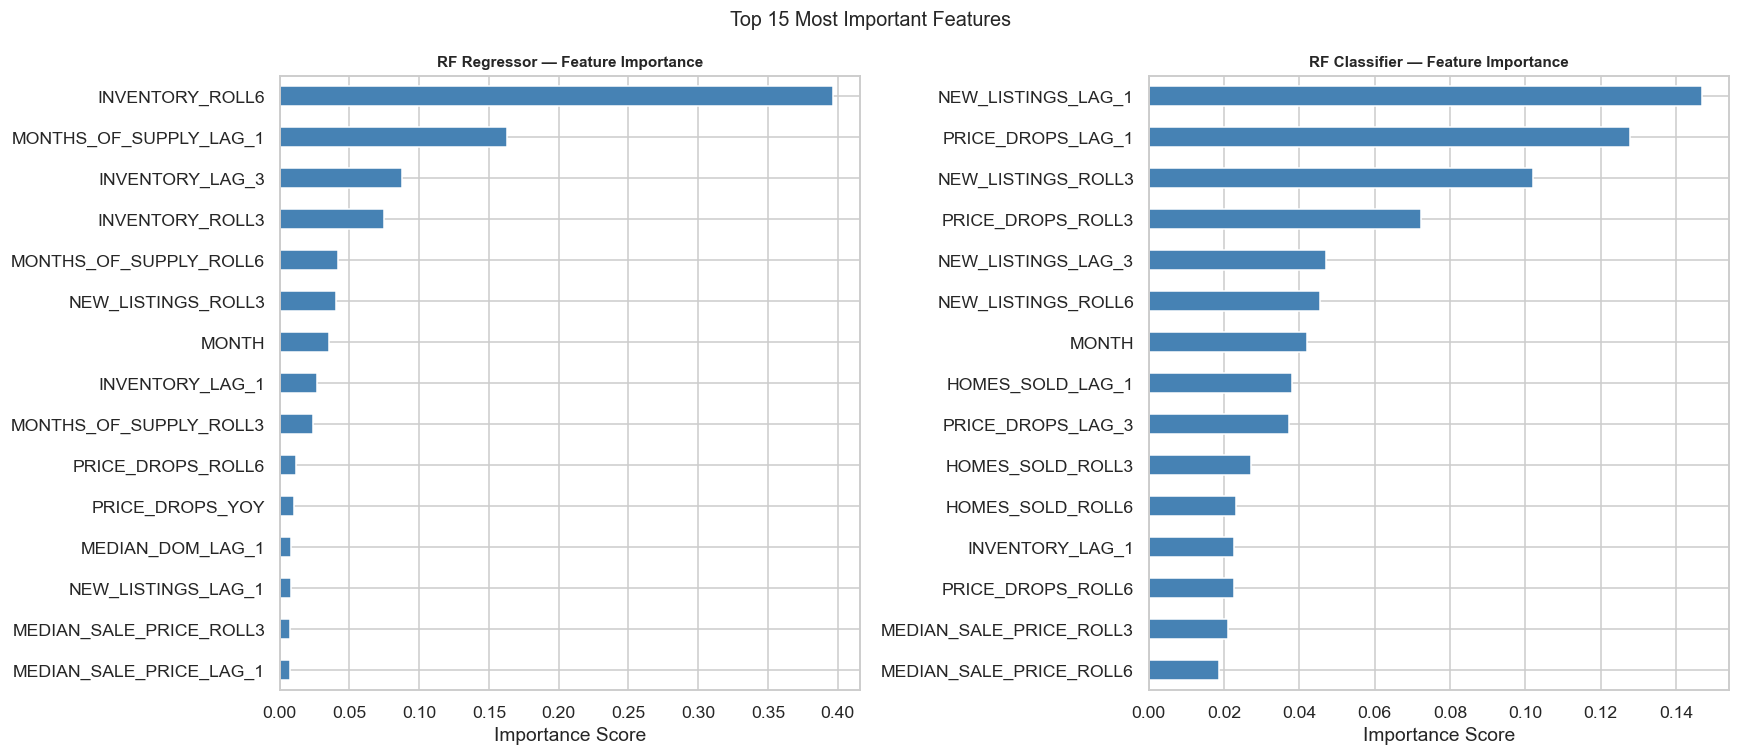

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model, name in [
    (axes[0], rf_reg, 'RF Regressor — Feature Importance'),
    (axes[1], rf_clf, 'RF Classifier — Feature Importance')
]:
    importances = pd.Series(model.feature_importances_, index=FEATURE_COLS)
    top15 = importances.sort_values(ascending=True).tail(15)
    top15.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('Top 15 Most Important Features', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Model Comparison Summary

### What are we doing in this cell?

We collect all test-set metrics into a single comparison table so we can decide which model to use for final predictions in notebook 06.

In [37]:
# Regression comparison
reg_results = []
for model, name in [(lr, 'Linear Regression'), (rf_reg, 'Random Forest Regressor')]:
    y_pred = model.predict(X_test_sc)
    reg_results.append({
        'Model': name,
        'R²':   round(r2_score(y_reg_test, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_reg_test, y_pred)), 4),
        'MAE':  round(mean_absolute_error(y_reg_test, y_pred), 4)
    })

print('=== REGRESSION RESULTS (test set) ===')
print(pd.DataFrame(reg_results).to_string(index=False))

# Classification comparison
clf_results = []
for model, name in [(log_clf, 'Logistic Regression'), (rf_clf, 'Random Forest Classifier')]:
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    from sklearn.metrics import f1_score
    clf_results.append({
        'Model':    name,
        'Accuracy': round(accuracy_score(y_clf_test, y_pred), 4),
        'F1':       round(f1_score(y_clf_test, y_pred, zero_division=0), 4),
        'AUC':      round(roc_auc_score(y_clf_test, y_prob), 4) if y_clf_test.nunique() == 2 else 'Not available'
    })

print('\n=== CLASSIFICATION RESULTS (test set) ===')
print(pd.DataFrame(clf_results).to_string(index=False))

=== REGRESSION RESULTS (test set) ===
                  Model      R²   RMSE    MAE
      Linear Regression  0.2362 0.2212 0.1826
Random Forest Regressor -0.6444 0.3245 0.2550

=== CLASSIFICATION RESULTS (test set) ===
                   Model  Accuracy  F1           AUC
     Logistic Regression       1.0 0.0 Not available
Random Forest Classifier       1.0 0.0 Not available


---
## Conclusion

Based on the test-set metrics above:

- **Best regression model** → the one with the highest R² and lowest RMSE
- **Best classification model** → the one with the highest AUC and F1 score

Generally, **Random Forest outperforms linear models** on tabular data because it captures non-linear relationships and feature interactions. However, the linear models serve as important baselines — if a complex model can't beat a simple one, something may be wrong.

**Next step →** Open `06_predictions.ipynb` to generate final predictions and visualise which periods are at highest listing risk.